# Denoising filters

pyclesperanto implements several filters commonly used to remove noise from images while trying to
preserve relevant structures:

- **[Gaussian blur](https://en.wikipedia.org/wiki/Gaussian_blur)**: smooths the image isotropically, efficient against
  Gaussian ("additive") noise but blurs edges.
- **[Median filter](https://en.wikipedia.org/wiki/Median_filter)**: replaces each pixel by the median of its neighborhood,
  very effective against impulse ("salt-and-pepper") noise while better preserving edges than a Gaussian blur.
- **[Kuwahara filter](https://en.wikipedia.org/wiki/Kuwahara_filter)**: an edge-preserving smoothing filter that averages
  over the neighboring region with the lowest variance, denoising flat areas while keeping edges sharp.

Real images are rarely affected by a single, pure type of noise. This notebook also shows how combining a Gaussian
blur and a median filter can help when an image is affected by a mix of Gaussian and impulse noise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.util import random_noise
from skimage.metrics import peak_signal_noise_ratio

import pyclesperanto as cle

cle.select_device()

(OpenCL) Apple M5 Max (OpenCL 1.2)
	Vendor:                      Apple
	Driver Version:              1.2 1.0
	Device Type:                 GPU
	Compute Units:               40
	Global Memory Size:          53084 MB
	Local Memory Size:           0 MB
	Maximum Buffer Size:         9953 MB
	Max Clock Frequency:         1000 MHz
	Image Support:               Yes

## Load the example image and generate noisy versions

We use `skimage.util.random_noise` to simulate three common noise scenarios:

- **Gaussian noise**: additive, normally distributed noise (e.g. sensor/read noise).
- **Salt & pepper noise**: impulse noise where random pixels are set to the minimum or maximum intensity.
- **Mixed noise**: a combination of both, which is closer to what is observed in some real acquisitions.

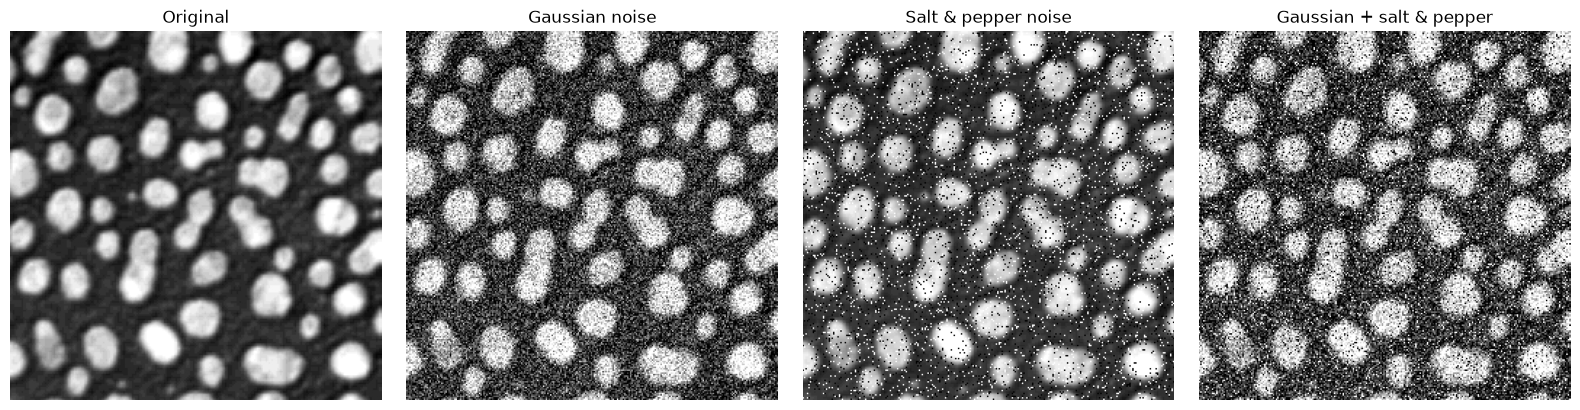

In [9]:
image = imread('https://samples.fiji.sc/blobs.png').squeeze().astype(np.float32)
image = image / image.max()

noisy_gaussian = random_noise(image, mode='gaussian', var=0.05).astype(np.float32)
noisy_salt_pepper = random_noise(image, mode='s&p', amount=0.1).astype(np.float32)
noisy_mixed = random_noise(noisy_gaussian, mode='s&p', amount=0.1).astype(np.float32)

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].imshow(image, cmap='gray')
axs[0].set_title('Original')
axs[1].imshow(noisy_gaussian, cmap='gray')
axs[1].set_title('Gaussian noise')
axs[2].imshow(noisy_salt_pepper, cmap='gray')
axs[2].set_title('Salt & pepper noise')
axs[3].imshow(noisy_mixed, cmap='gray')
axs[3].set_title('Gaussian + salt & pepper')
for ax in axs.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

In [10]:
# SNR between original and noisy images
print('PSNR original -> gaussian noise:', peak_signal_noise_ratio(image, noisy_gaussian))
print('PSNR original -> salt&pepper noise:', peak_signal_noise_ratio(image, noisy_salt_pepper))
print('PSNR original -> mixed noise:', peak_signal_noise_ratio(image, noisy_mixed))

PSNR original -> gaussian noise: 14.329902200002017
PSNR original -> salt&pepper noise: 14.757906528513447
PSNR original -> mixed noise: 11.812417302040725


In [11]:
image_gpu = cle.push(image)
noisy_gaussian_gpu = cle.push(noisy_gaussian)
noisy_salt_pepper_gpu = cle.push(noisy_salt_pepper)
noisy_mixed_gpu = cle.push(noisy_mixed)

## 1. Gaussian blur

`cle.gaussian_blur()` is well suited for Gaussian noise: it averages neighboring pixels with weights following a
Gaussian distribution, which reduces additive noise efficiently. However, being a linear filter, it also blurs
edges and fine structures, and it barely removes strong outlier pixels such as salt & pepper noise.

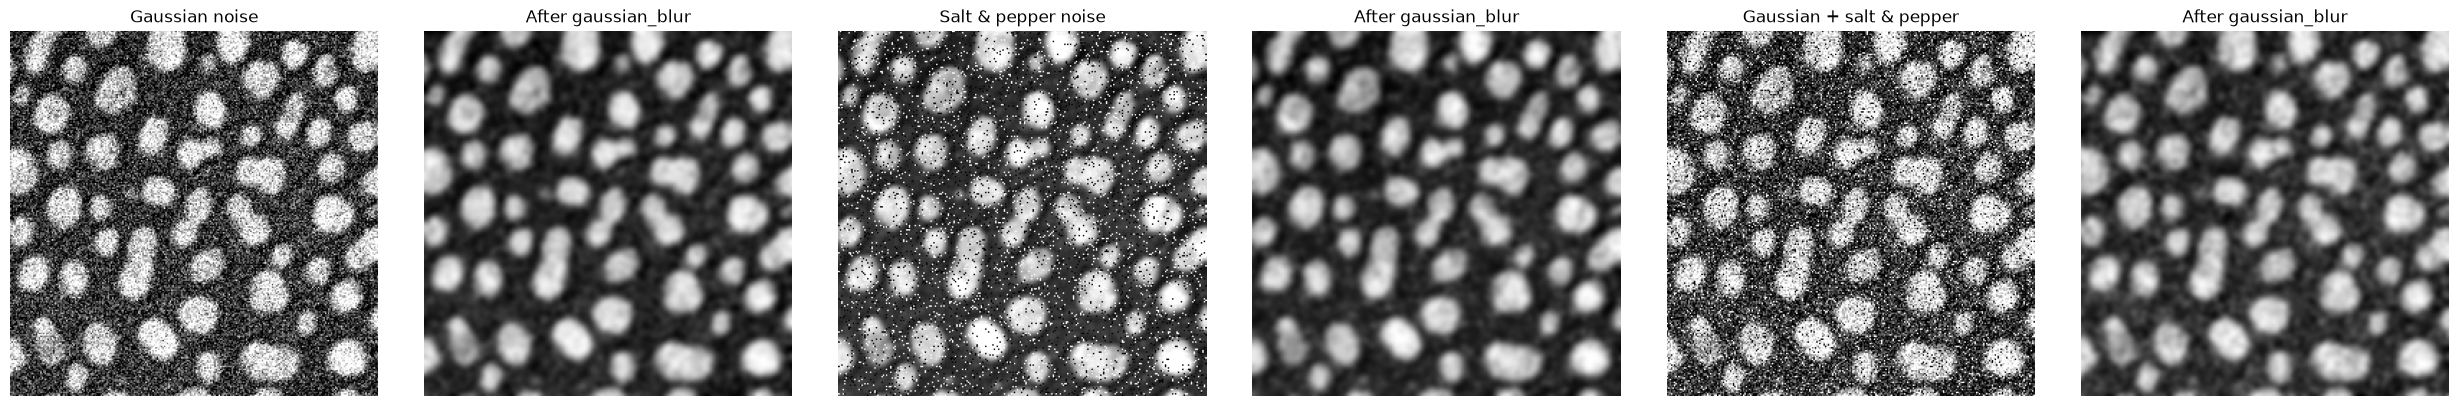

PSNR gaussian noise -> gaussian_blur: 22.991121379428105
PSNR salt&pepper noise -> gaussian_blur: 23.119231200566503
PSNR mixed noise -> gaussian_blur: 20.69512537849905


In [12]:
gaussian_denoised = cle.gaussian_blur(noisy_gaussian_gpu, sigma_x=2, sigma_y=2)
gaussian_on_salt_pepper = cle.gaussian_blur(noisy_salt_pepper_gpu, sigma_x=2, sigma_y=2)
gaussian_on_noisy_mixed = cle.gaussian_blur(noisy_mixed_gpu, sigma_x=2, sigma_y=2)

fig, axs = plt.subplots(1, 6, figsize=(25, 4))
axs[0].imshow(noisy_gaussian_gpu, cmap='gray')
axs[0].set_title('Gaussian noise')
axs[1].imshow(gaussian_denoised, cmap='gray')
axs[1].set_title('After gaussian_blur')
axs[2].imshow(noisy_salt_pepper_gpu, cmap='gray')
axs[2].set_title('Salt & pepper noise')
axs[3].imshow(gaussian_on_salt_pepper, cmap='gray')
axs[3].set_title('After gaussian_blur')
axs[4].imshow(noisy_mixed_gpu, cmap='gray')
axs[4].set_title('Gaussian + salt & pepper')
axs[5].imshow(gaussian_on_noisy_mixed, cmap='gray')
axs[5].set_title('After gaussian_blur')
for ax in axs.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

print('PSNR gaussian noise -> gaussian_blur:', peak_signal_noise_ratio(image, gaussian_denoised.get()))
print('PSNR salt&pepper noise -> gaussian_blur:', peak_signal_noise_ratio(image, gaussian_on_salt_pepper.get()))
print('PSNR mixed noise -> gaussian_blur:', peak_signal_noise_ratio(image, gaussian_on_noisy_mixed.get()))

## 2. Median filter

`cle.median()` replaces every pixel by the median value of its neighborhood. Because it does not average
intensities, it is very effective at removing outlier pixels (salt & pepper noise) while keeping edges sharper
than a Gaussian blur. It is, however, less efficient than the Gaussian blur against purely additive Gaussian
noise, and can remove very small, thin structures if the radius is too large.

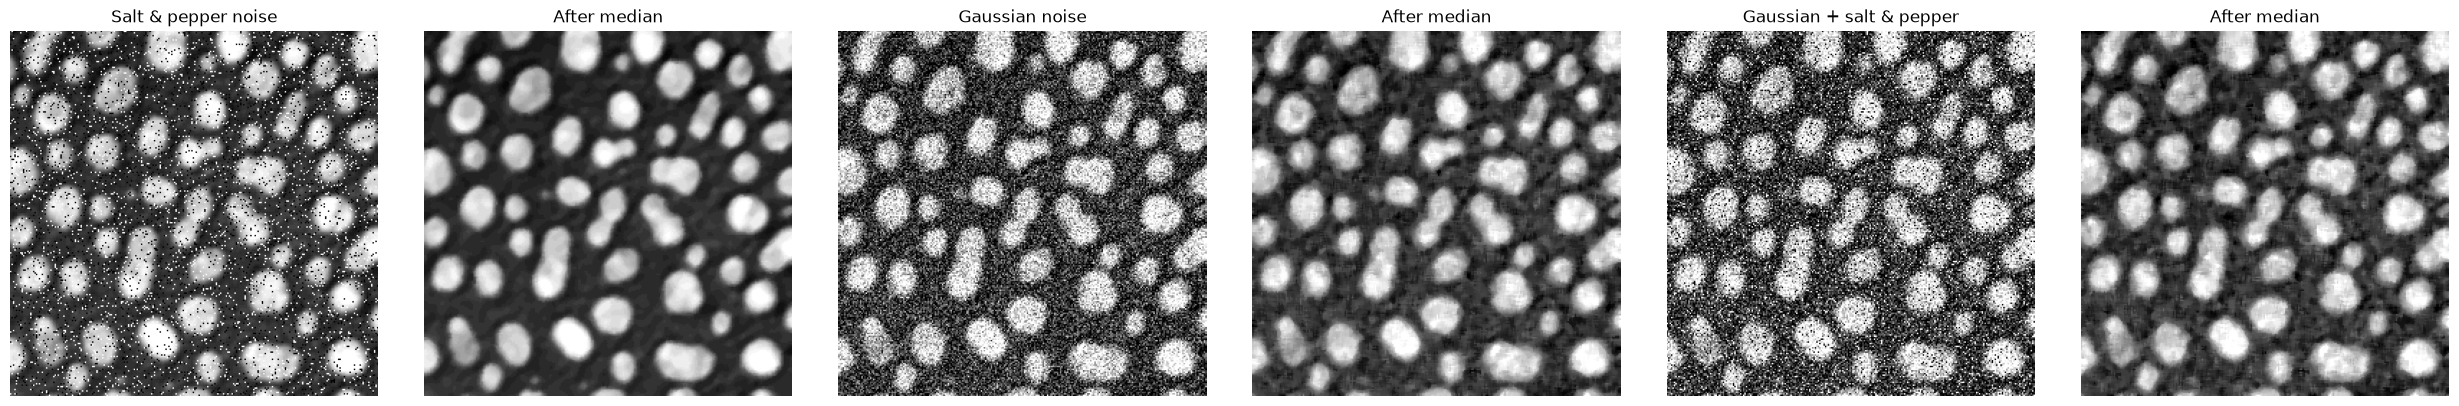

PSNR salt&pepper noise -> median: 31.38645579103269
PSNR gaussian noise -> median: 23.800906052861528
PSNR mixed noise -> median: 22.967498194632697


In [13]:
median_denoised = cle.median(noisy_salt_pepper_gpu, radius_x=2, radius_y=2)
median_on_gaussian = cle.median(noisy_gaussian_gpu, radius_x=2, radius_y=2)
median_on_noisy_mixed = cle.median(noisy_mixed_gpu, radius_x=2, radius_y=2)

fig, axs = plt.subplots(1, 6, figsize=(25, 4))
axs[0].imshow(noisy_salt_pepper_gpu, cmap='gray')
axs[0].set_title('Salt & pepper noise')
axs[1].imshow(median_denoised, cmap='gray')
axs[1].set_title('After median')
axs[2].imshow(noisy_gaussian_gpu, cmap='gray')
axs[2].set_title('Gaussian noise')
axs[3].imshow(median_on_gaussian, cmap='gray')
axs[3].set_title('After median')
axs[4].imshow(noisy_mixed_gpu, cmap='gray')
axs[4].set_title('Gaussian + salt & pepper')
axs[5].imshow(median_on_noisy_mixed, cmap='gray')
axs[5].set_title('After median')
for ax in axs.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

print('PSNR salt&pepper noise -> median:', peak_signal_noise_ratio(image, median_denoised.get()))
print('PSNR gaussian noise -> median:', peak_signal_noise_ratio(image, median_on_gaussian.get()))
print('PSNR mixed noise -> median:', peak_signal_noise_ratio(image, median_on_noisy_mixed.get()))

## 3. Kuwahara filter

`cle.kuwahara_filter()` is an edge-preserving smoothing filter: the neighborhood of each pixel is split into
regions (quadrants in 2D), and the output is a weighted blend favoring regions with the lowest local variance.
This denoises homogeneous areas while keeping sharp edges, at the cost of sometimes introducing a slightly
"painterly" look on textured regions.

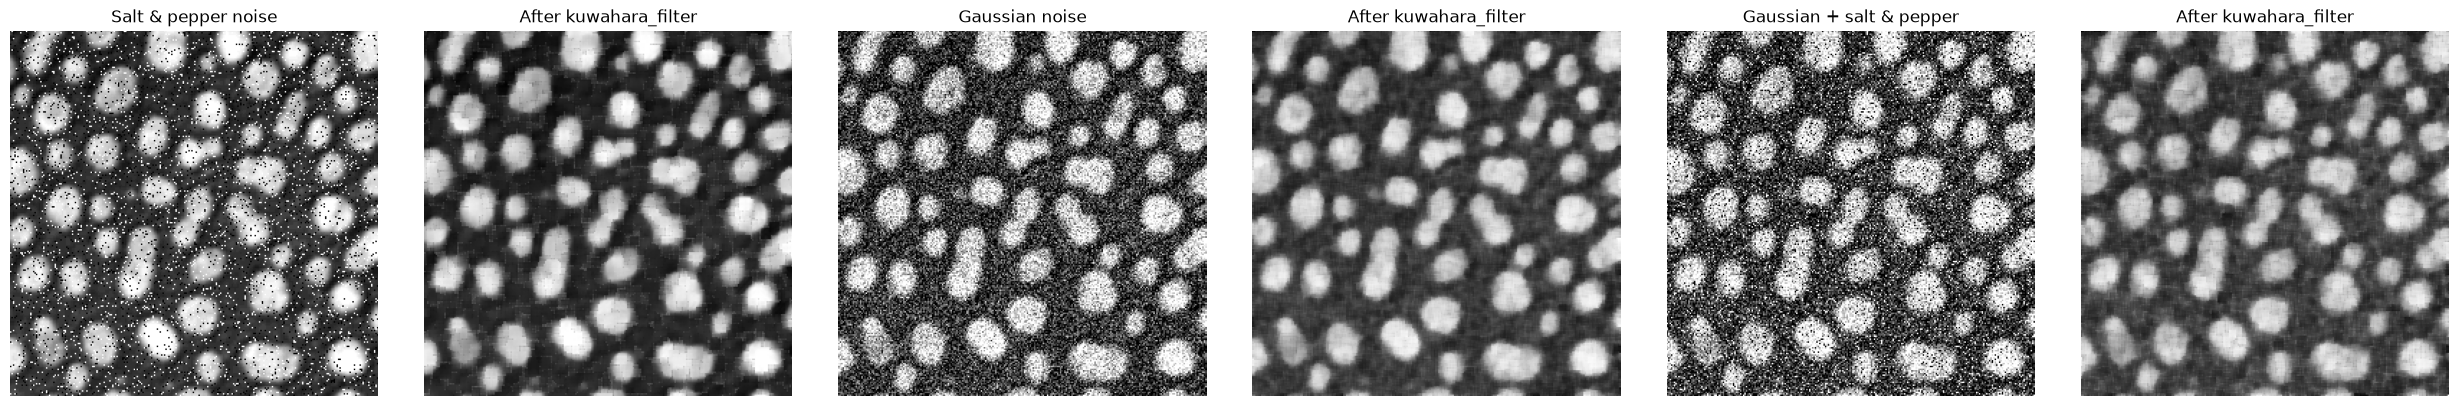

PSNR salt&pepper noise -> kuwahara_filter: 24.774041448540302
PSNR gaussian noise -> kuwahara_filter: 23.900205869461
PSNR mixed noise -> kuwahara_filter: 21.342721832706776


In [14]:
kuwahara_salt_pepper = cle.kuwahara_filter(noisy_salt_pepper_gpu, radius=3, sigma=2)
kuwahara_gaussian = cle.kuwahara_filter(noisy_gaussian_gpu, radius=3, sigma=2)
kuwahara_mixed = cle.kuwahara_filter(noisy_mixed_gpu, radius=3, sigma=2)

fig, axs = plt.subplots(1, 6, figsize=(25, 4))
axs[0].imshow(noisy_salt_pepper_gpu, cmap='gray')
axs[0].set_title('Salt & pepper noise')
axs[1].imshow(kuwahara_salt_pepper, cmap='gray')
axs[1].set_title('After kuwahara_filter')
axs[2].imshow(noisy_gaussian_gpu, cmap='gray')
axs[2].set_title('Gaussian noise')
axs[3].imshow(kuwahara_gaussian, cmap='gray')
axs[3].set_title('After kuwahara_filter')
axs[4].imshow(noisy_mixed_gpu, cmap='gray')
axs[4].set_title('Gaussian + salt & pepper')
axs[5].imshow(kuwahara_mixed, cmap='gray')
axs[5].set_title('After kuwahara_filter')
for ax in axs.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

print('PSNR salt&pepper noise -> kuwahara_filter:', peak_signal_noise_ratio(image, kuwahara_salt_pepper.get()))
print('PSNR gaussian noise -> kuwahara_filter:', peak_signal_noise_ratio(image, kuwahara_gaussian.get()))
print('PSNR mixed noise -> kuwahara_filter:', peak_signal_noise_ratio(image, kuwahara_mixed.get()))

## 4. Combining Gaussian blur and median filter for mixed noise

Real images are frequently affected by more than one type of noise at once, for example a combination of
Gaussian (sensor) noise and impulse (salt & pepper) noise. In that case, applying a single filter is often a
compromise: a median filter alone leaves residual Gaussian noise, while a Gaussian blur alone does not remove
outlier pixels efficiently.

A common strategy is to chain both filters: first apply a median filter to remove the impulse noise outliers,
then apply a Gaussian blur to smooth out the remaining additive noise.

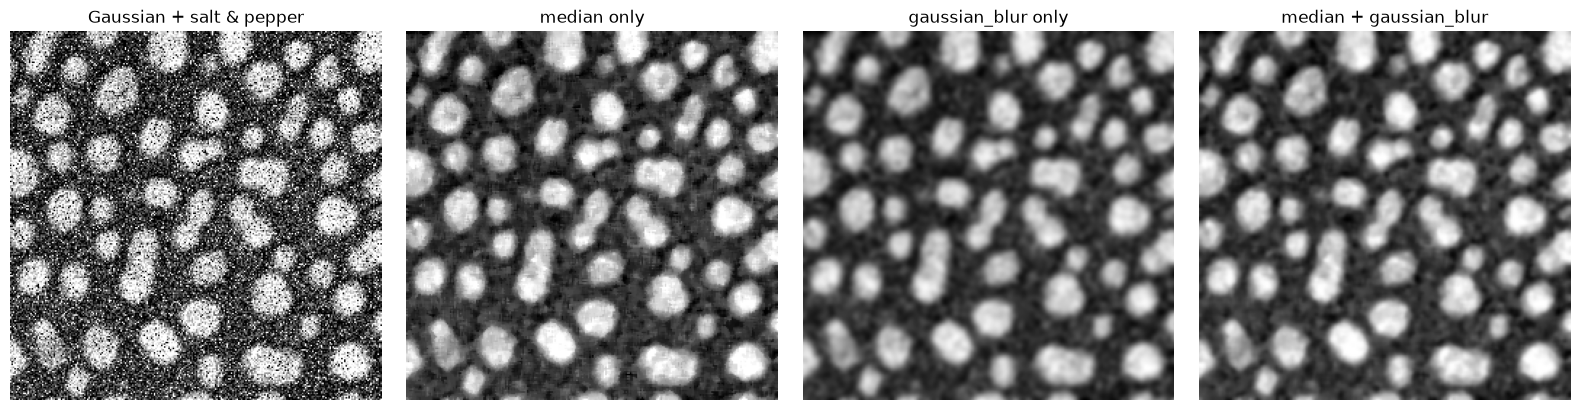

PSNR mixed noise: 11.812417302040725
PSNR median only: 22.967498194632697
PSNR gaussian_blur only: 20.69512537849905
PSNR median + gaussian_blur: 24.339138438827078


In [15]:
median_only = cle.median(noisy_mixed_gpu, radius_x=2, radius_y=2)
gaussian_only = cle.gaussian_blur(noisy_mixed_gpu, sigma_x=2, sigma_y=2)
median_then_gaussian = cle.gaussian_blur(median_only, sigma_x=1, sigma_y=1)

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].imshow(noisy_mixed_gpu, cmap='gray')
axs[0].set_title('Gaussian + salt & pepper')
axs[1].imshow(median_only, cmap='gray')
axs[1].set_title('median only')
axs[2].imshow(gaussian_only, cmap='gray')
axs[2].set_title('gaussian_blur only')
axs[3].imshow(median_then_gaussian, cmap='gray')
axs[3].set_title('median + gaussian_blur')
for ax in axs.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

print('PSNR mixed noise:', peak_signal_noise_ratio(image, noisy_mixed))
print('PSNR median only:', peak_signal_noise_ratio(image, median_only.get()))
print('PSNR gaussian_blur only:', peak_signal_noise_ratio(image, gaussian_only.get()))
print('PSNR median + gaussian_blur:', peak_signal_noise_ratio(image, median_then_gaussian.get()))

> On mixed noise, chaining a median filter (to remove impulse outliers) followed by a mild Gaussian blur
> (to smooth remaining additive noise) typically outperforms either filter used alone, as reflected by a higher
> PSNR. The order matters: applying the median filter first avoids spreading salt & pepper outliers into their
> neighborhood, which is what a Gaussian blur applied first would do.